<h1>Classification Challenge – Score Maximiser</h1>

**Scoring formula (evaluated on 10,000 test images)**

| Correct predictions | Reward per correct |
|---|---|
| First 5,000 | 100 € |
| 5,001 – 6,000 | 200 € |
| Beyond 6,000 | 1,000 € |

**Penalty:** subtract the model's total parameter count from the reward.  
**Net Score = Reward − TotalParams**

Goal: maximise accuracy while keeping the model small.

Import TensorFlow (deep learning library), NumPy (numerical operations) and Matplotlib (plots). Printing the TensorFlow version is useful because some behaviours can differ between versions.

In [23]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TF:", tf.__version__)

TF: 2.16.2


<h2>Configuration – edit here to swap dataset</h2>

Change `DATASET_NAME` to `'mnist'` or `'cifar10'` and re-run all cells. Everything else adapts automatically.

Feel free to tune `EPOCHS`, `BATCH_SIZE`, and `LEARN_RATE` to improve the score.

In [24]:
# ── CHANGE 1 of 3 ─────────────────────────────────────────────────────────────
# Replace 'my_dataset' with any short label you like, e.g. 'cats_vs_dogs'.
# This name is only used in print statements and the CLASS_NAMES dict below.
DATASET_NAME = 'mnist'  # ← rename to e.g. 'cats_vs_dogs'

# Number of images used for the final score (always 10,000)
EVAL_SIZE = 10_000

# Training settings
EPOCHS     = 15    # passes through the training data
BATCH_SIZE = 128   # samples per gradient update
LEARN_RATE = 1e-3  # step size for the Adam optimiser
VAL_SPLIT  = 0.1   # fraction of training data held out for validation

# Where to save the trained model
MODEL_SAVE_PATH = 'challenge_model.keras'

<h2>Load and preprocess data</h2>

Pixel values are rescaled from [0, 255] to [0.0, 1.0]. This stabilises gradient updates and speeds up training considerably — the same model converges faster and achieves higher accuracy with normalised input than without.

For grayscale datasets (Fashion-MNIST, MNIST) the image array has shape `(N, H, W)`. We add a channel dimension to get `(N, H, W, 1)` so the model always receives a consistent 4-D tensor.

In [25]:
# ── CHANGE 2 of 3 ─────────────────────────────────────────────────────────────
# Replace everything between the two markers with your own loader.
# The code below the second marker must stay unchanged.

# ▼▼▼  LOADER START — replace this block with your own data loading  ▼▼▼

# OPTION A – Images in folders (most common for custom datasets)
#
# Expected layout:
#   my_dataset/
#     train/  class_one/  class_two/  ...
#     test/   class_one/  class_two/  ...
#
# train_ds = tf.keras.utils.image_dataset_from_directory(
#     'my_dataset/train', image_size=(64, 64), batch_size=BATCH_SIZE, label_mode='int', shuffle=True)
# test_ds  = tf.keras.utils.image_dataset_from_directory(
#     'my_dataset/test',  image_size=(64, 64), batch_size=BATCH_SIZE, label_mode='int', shuffle=False)
# x_train = np.concatenate([x for x, y in train_ds], axis=0)
# y_train = np.concatenate([y for x, y in train_ds], axis=0)
# x_test  = np.concatenate([x for x, y in test_ds],  axis=0)
# y_test  = np.concatenate([y for x, y in test_ds],  axis=0)

# OPTION B – NumPy .npy files
#
# x_train = np.load('my_dataset_x_train.npy')
# y_train = np.load('my_dataset_y_train.npy')
# x_test  = np.load('my_dataset_x_test.npy')
# y_test  = np.load('my_dataset_y_test.npy')

# OPTION C – Keras built-in (default, works out of the box)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
#                                        ^^^^^^^^^^^^^^^^^^^^^
#                                        swap to .mnist or .cifar10 if needed

# ▲▲▲  LOADER END — do not change anything below this line  ▲▲▲

# Normalise pixel values from [0, 255] to [0.0, 1.0]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# Add channel dimension for grayscale images: (N, H, W) → (N, H, W, 1)
# Colour images like CIFAR-10 already have shape (N, H, W, 3) — skipped automatically
if x_train.ndim == 3:
    x_train = x_train[..., np.newaxis]
    x_test  = x_test[..., np.newaxis]

# Derive shape and class count directly from the data
INPUT_SHAPE = x_train.shape[1:]           # e.g. (28, 28, 1) or (32, 32, 3)
NUM_CLASSES = len(np.unique(y_train))     # e.g. 10 for Fashion-MNIST

# Flatten labels to 1-D integers (required by sparse_categorical_crossentropy)
y_train = y_train.flatten()
y_test  = y_test.flatten()

# Fixed evaluation slice for scoring
x_eval = x_test[:EVAL_SIZE]
y_eval = y_test[:EVAL_SIZE]

print(f"Dataset      : {DATASET_NAME}")
print(f"Input shape  : {INPUT_SHAPE}")
print(f"Classes      : {NUM_CLASSES}")
print(f"Train samples: {len(x_train):,}")
print(f"Eval samples : {len(x_eval):,}")

Dataset      : mnist
Input shape  : (28, 28, 1)
Classes      : 10
Train samples: 60,000
Eval samples : 10,000


<h2>Build the model (CNN)</h2>

A convolutional neural network is a better fit for images than a plain dense network, because it preserves spatial structure — edges, textures and shapes are detected by small filters that slide across the image rather than pixel-by-pixel connections that lose all position information.

Architecture used here (deliberately small to limit the parameter penalty):

- **Conv2D(16)** — detects basic edges and textures with 16 different 3×3 filters
- **MaxPool2D** — halves H×W, keeps the strongest activation in each 2×2 window
- **Conv2D(32)** — combines block-1 patterns into richer shapes
- **MaxPool2D** — halves again
- **Flatten** — converts the 3-D feature map into a 1-D vector
- **Dense(64)** — small decision head
- **Dense(NUM_CLASSES, softmax)** — one neuron per class, outputs a probability distribution

Total parameters on Fashion-MNIST: about 48,000 — a dense-only model of comparable accuracy would need several hundred thousand.

In [26]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=INPUT_SHAPE),

    # Block 1 – extract local patterns
    tf.keras.layers.Conv2D(16, 3, activation='relu'),
    tf.keras.layers.MaxPool2D(),

    # Block 2 – combine patterns into larger concepts
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPool2D(),

    # Classification head
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'),  # one output per class

], name='minimal_cnn')

model.summary()
print(f"\nTotal parameters : {model.count_params():,}")
print(f"Parameter penalty: -{model.count_params():,}")

Model: "minimal_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,714 (221.54 KB)

 Trainable params: 56,714 (221.54 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters : 56,714
Parameter penalty: -56,714


<h2>Compile</h2>

Compilation wires the model to a loss function and an optimiser. The Adam optimiser adjusts the learning rate per parameter automatically, making it a reliable default. Sparse categorical cross-entropy is the correct loss when class labels are plain integers rather than one-hot vectors.

In [27]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARN_RATE),
    loss='sparse_categorical_crossentropy',  # labels are ints, not one-hot
    metrics=['accuracy']
)

<h2>Train</h2>

`model.fit` runs the training loop. On each epoch the model makes predictions on batches, computes the loss, and uses the optimiser to adjust weights.

Early stopping halts training automatically when validation loss stops improving — this prevents overfitting without manually tuning the epoch count. Setting `restore_best_weights=True` rolls back to the best checkpoint.

In [28]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining complete.")

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - accuracy: 0.9141 - loss: 0.3019 - val_accuracy: 0.9775 - val_loss: 0.0823
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.9759 - loss: 0.0784 - val_accuracy: 0.9842 - val_loss: 0.0615
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.9833 - loss: 0.0560 - val_accuracy: 0.9862 - val_loss: 0.0486
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.9862 - loss: 0.0447 - val_accuracy: 0.9887 - val_loss: 0.0425
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.9887 - loss: 0.0376 - val_accuracy: 0.9873 - val_loss: 0.0500
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.9907 - loss: 0.0308 - val_accuracy: 0.9870 - val_loss: 0.0422
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.9914 - loss: 0.0272 - val_accuracy: 0.9887 - val_loss: 0.0385
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.9925 - loss: 0.0232 - 

<h2>Save the model</h2>

The `.keras` format is the recommended modern format in TensorFlow/Keras. It stores the architecture, weights, and compile configuration in a single file. To reload later: `keras.models.load_model('challenge_model.keras')`

In [29]:
model.save(MODEL_SAVE_PATH)
print(f"Model saved → {MODEL_SAVE_PATH}")

Model saved → challenge_model.keras


<h2>Model diagram</h2>

`plot_model` requires the `pydot` and `graphviz` packages. Install once with:

```
pip install pydot graphviz
```

If they are not installed the cell falls back gracefully to the text summary.

In [30]:
import subprocess
result = subprocess.run(['find', '/opt/homebrew', '/usr/local', '-name', 'dot', '-type', 'f'], 
                       capture_output=True, text=True)
print(result.stdout)

/usr/local/Cellar/graphviz/14.1.3/bin/dot



In [31]:
import os
for p in ['/opt/homebrew/bin', '/usr/local/bin']:
    if p not in os.environ['PATH']:
        os.environ['PATH'] = p + ':' + os.environ['PATH']

DIAGRAM_PATH = 'model_diagram.png'

try:
    tf.keras.utils.plot_model(
        model,
        to_file=DIAGRAM_PATH,
        show_shapes=True,
        show_layer_names=True,
        dpi=96
    )
#     from IPython.display import Image, display
#     display(Image(DIAGRAM_PATH))
#     print(f"Diagram saved → {DIAGRAM_PATH}")
    
except Exception as e:
    print("Diagram skipped — install pydot + graphviz to enable PNG diagrams.")
    print(f"  Reason: {e}")
    print("\nText summary instead:")
    model.summary()


<h2>Training curves</h2>

Plotting training vs validation loss and accuracy shows whether the model is still improving or starting to overfit. A growing gap between the two lines is a sign that the model is memorising the training set rather than learning a general rule.

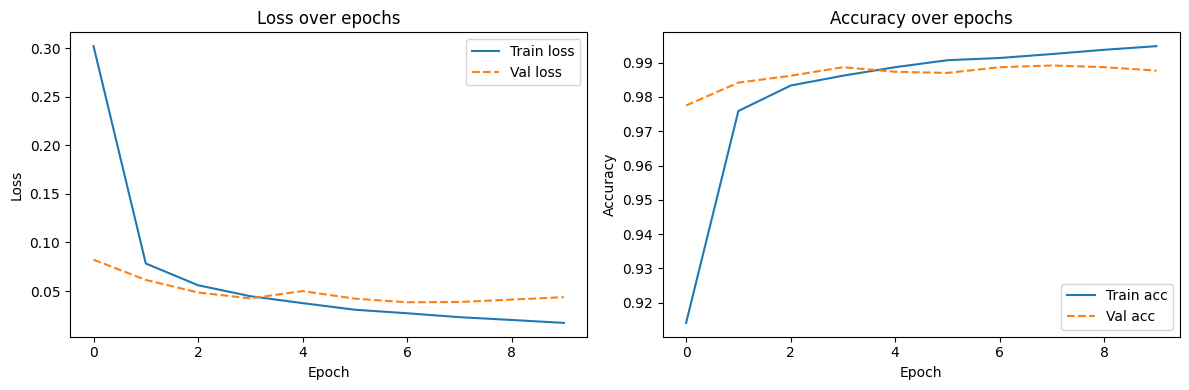

Saved → training_curves.png


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss', linestyle='--')
axes[0].set_title('Loss over epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train acc')
axes[1].plot(history.history['val_accuracy'], label='Val acc', linestyle='--')
axes[1].set_title('Accuracy over epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=96)
plt.show()
print("Saved → training_curves.png")

<h2>Evaluate and calculate score</h2>

We run `model.predict` on the fixed 10,000-image evaluation slice, count correct predictions, apply the tiered reward, and subtract the parameter penalty.

In [33]:
y_pred_probs = model.predict(x_eval, verbose=0)   # shape: (10000, NUM_CLASSES)
y_pred       = np.argmax(y_pred_probs, axis=1)     # predicted class per image
correct      = int(np.sum(y_pred == y_eval))        # total correct out of 10,000

print(f"Correct predictions : {correct:,} / {EVAL_SIZE:,}")
print(f"Accuracy            : {correct / EVAL_SIZE:.2%}")

# Tiered reward
tier1 = min(correct, 5_000) * 100
tier2 = max(0, min(correct, 6_000) - 5_000) * 200
tier3 = max(0, correct - 6_000) * 1_000
reward = tier1 + tier2 + tier3

total_params = model.count_params()
net_score    = reward - total_params

print()
print("══════════════════════════════════════════")
print("          SCORING BREAKDOWN               ")
print("══════════════════════════════════════════")
print(f"  Tier 1 (≤5,000 @ 100 €)    : {tier1:>12,.0f} €")
print(f"  Tier 2 (5,001–6,000 @ 200€) : {tier2:>12,.0f} €")
print(f"  Tier 3 (>6,000 @ 1,000 €)  : {tier3:>12,.0f} €")
print(f"  Total reward                : {reward:>12,.0f} €")
print(f"  Parameter penalty           : {total_params:>12,}")
print("──────────────────────────────────────────")
print(f"  NET SCORE                   : {net_score:>12,.0f}")
print("══════════════════════════════════════════")

Correct predictions : 9,883 / 10,000
Accuracy            : 98.83%

══════════════════════════════════════════
          SCORING BREAKDOWN               
══════════════════════════════════════════
  Tier 1 (≤5,000 @ 100 €)    :      500,000 €
  Tier 2 (5,001–6,000 @ 200€) :      200,000 €
  Tier 3 (>6,000 @ 1,000 €)  :    3,883,000 €
  Total reward                :    4,583,000 €
  Parameter penalty           :       56,714
──────────────────────────────────────────
  NET SCORE                   :    4,526,286
══════════════════════════════════════════


<h2>Sample predictions</h2>

Showing a few test images alongside predicted and true labels makes it immediately clear whether the model is confused by particular classes. Green titles indicate a correct prediction, red titles indicate a mistake.

Numbers summarise performance; plots explain it.

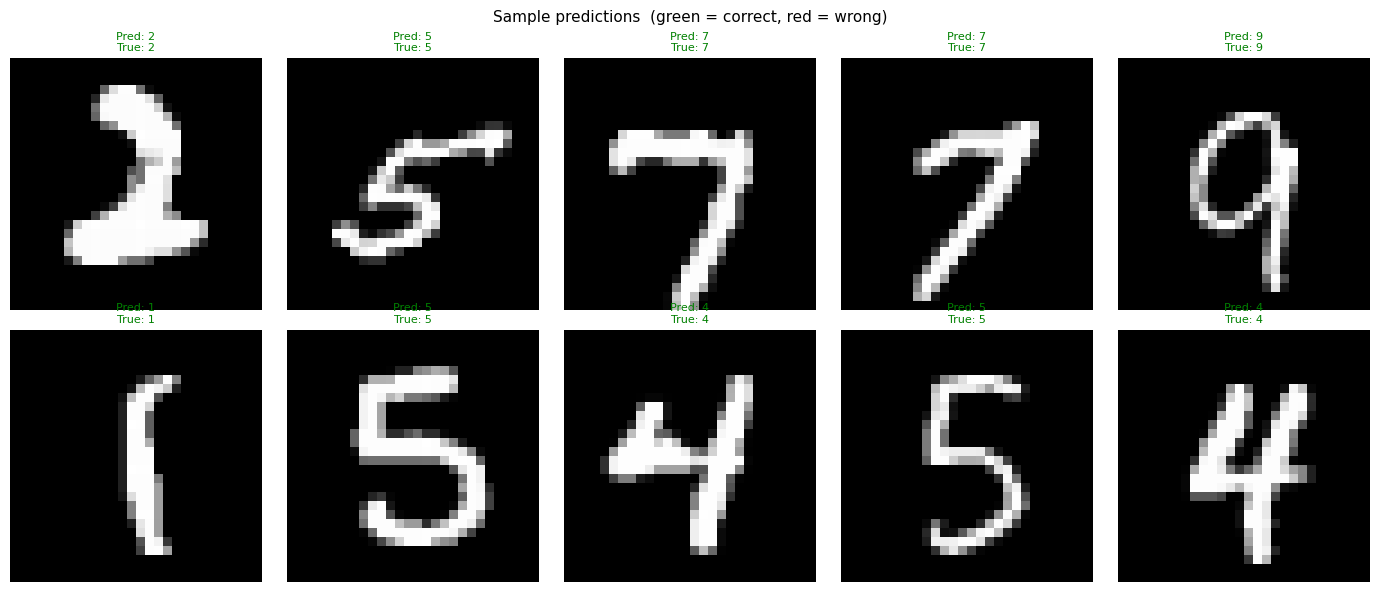

Saved → sample_predictions.png


In [34]:
# ── CHANGE 3 of 3 ─────────────────────────────────────────────────────────────
# Add your dataset's class names to the dict below.
# The key must match DATASET_NAME set in the config cell.
CLASS_NAMES = {
    'fashion_mnist': ['T-shirt','Trouser','Pullover','Dress','Coat',
                      'Sandal','Shirt','Sneaker','Bag','Ankle boot'],
    'mnist':         [str(i) for i in range(10)],
    'cifar10':       ['airplane','automobile','bird','cat','deer',
                      'dog','frog','horse','ship','truck'],
    # ↓ add your dataset here
    'my_dataset':    ['class_zero', 'class_one', 'class_two'],  # ← replace with real names
}
names = CLASS_NAMES.get(DATASET_NAME, [str(i) for i in range(NUM_CLASSES)])

rng  = np.random.default_rng(seed=0)
idxs = rng.choice(EVAL_SIZE, size=10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, i in zip(axes.flat, idxs):
    img = x_eval[i]
    if img.shape[-1] == 1:
        img = img.squeeze(-1)
    ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
    pred   = names[y_pred[i]]
    truth  = names[y_eval[i]]
    colour = 'green' if y_pred[i] == y_eval[i] else 'red'
    ax.set_title(f"Pred: {pred}\nTrue: {truth}", color=colour, fontsize=8)
    ax.axis('off')

plt.suptitle('Sample predictions  (green = correct, red = wrong)', fontsize=11)
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=96)
plt.show()
print("Saved → sample_predictions.png")